In [27]:
import pandas as pd

In [28]:
train_df = pd.read_csv("data/race_results_22_24.csv")
test_df = pd.read_csv("data/race_results_25.csv")

print(train_df.head())

  Abbreviation      TeamName  GridPosition  Position  Points  Season  \
0          LEC       Ferrari           1.0       1.0    26.0    2022   
1          SAI       Ferrari           3.0       2.0    18.0    2022   
2          HAM      Mercedes           5.0       3.0    15.0    2022   
3          RUS      Mercedes           9.0       4.0    12.0    2022   
4          MAG  Haas F1 Team           7.0       5.0    10.0    2022   

   RoundNumber           EventName  Podium  Rainfall  AirTemp  
0            1  Bahrain Grand Prix       1     False     23.2  
1            1  Bahrain Grand Prix       1     False     23.2  
2            1  Bahrain Grand Prix       1     False     23.2  
3            1  Bahrain Grand Prix       0     False     23.2  
4            1  Bahrain Grand Prix       0     False     23.2  


# Data Engineering

In [29]:
# Get total points up to that race
train_df = train_df.sort_values(['Season', 'RoundNumber'])
test_df = test_df.sort_values(['Season', 'RoundNumber'])

train_df['DriverPointsBefore'] = (
    train_df.groupby(['Abbreviation', 'Season'])['Points']
    .cumsum()
    .shift(1)
    .fillna(0)
)
test_df['DriverPointsBefore'] = (
    test_df.groupby(['Abbreviation', 'Season'])['Points']
    .cumsum()
    .shift(1)
    .fillna(0)
)


In [30]:
# Constructors points up to that point

train_df['TeamPointsBefore'] = (
    train_df.groupby(['TeamName', 'Season'])['Points']
    .cumsum()
    .shift(1)
    .fillna(0)
)
test_df['TeamPointsBefore'] = (
    test_df.groupby(['TeamName', 'Season'])['Points']
    .cumsum()
    .shift(1)
    .fillna(0)
)


In [31]:
# Averge finsish last 3 races

train_df['AvgFinishLast3'] = (
    train_df.groupby(['Abbreviation', 'Season'])['Position']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

test_df['AvgFinishLast3'] = (
    test_df.groupby(['Abbreviation', 'Season'])['Position']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

In [32]:
cols_to_keep = [
    'Abbreviation',
    'TeamName',
    'GridPosition',
    'DriverPointsBefore',
    'TeamPointsBefore',
    'AvgFinishLast3',
    'Rainfall',
    'AirTemp',
    'Podium'
]

train_df = train_df[cols_to_keep]
test_df = test_df[cols_to_keep]

train_df.to_csv("data/race_results_22_24_clean.csv", index=False)
test_df.to_csv("data/race_results_25_clean.csv", index=False)



# EDA

In [33]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Abbreviation        1359 non-null   object 
 1   TeamName            1359 non-null   object 
 2   GridPosition        1357 non-null   float64
 3   DriverPointsBefore  1359 non-null   float64
 4   TeamPointsBefore    1359 non-null   float64
 5   AvgFinishLast3      1291 non-null   float64
 6   Rainfall            1359 non-null   bool   
 7   AirTemp             1359 non-null   float64
 8   Podium              1359 non-null   int64  
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 86.4+ KB


Abbreviation           0
TeamName               0
GridPosition           2
DriverPointsBefore     0
TeamPointsBefore       0
AvgFinishLast3        68
Rainfall               0
AirTemp                0
Podium                 0
dtype: int64

array([[<Axes: title={'center': 'GridPosition'}>,
        <Axes: title={'center': 'DriverPointsBefore'}>],
       [<Axes: title={'center': 'TeamPointsBefore'}>,
        <Axes: title={'center': 'AvgFinishLast3'}>],
       [<Axes: title={'center': 'AirTemp'}>,
        <Axes: title={'center': 'Podium'}>]], dtype=object)

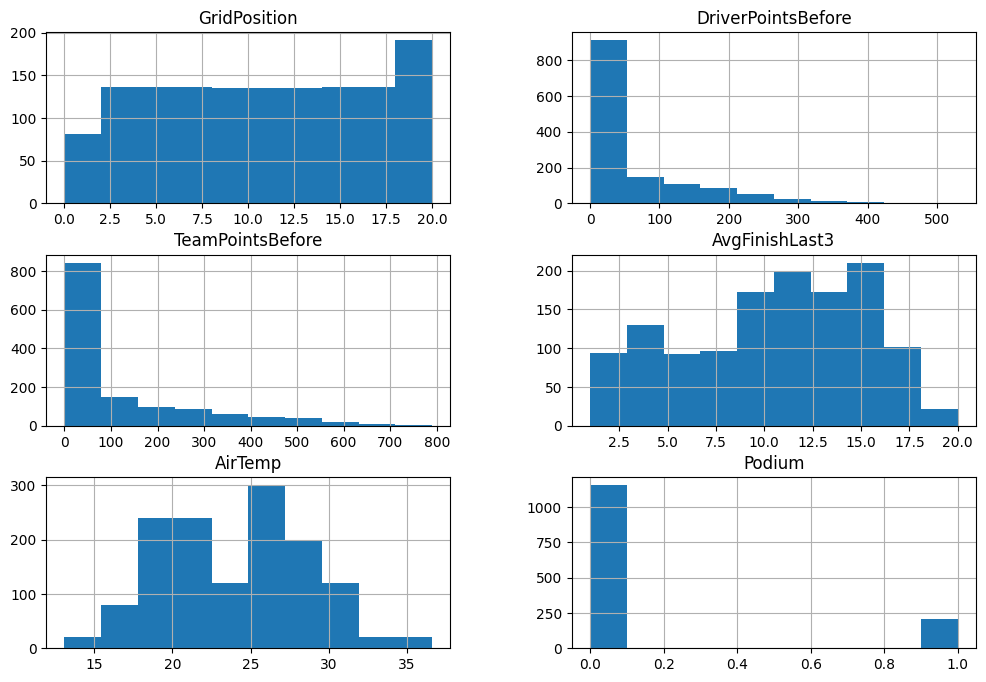

In [34]:
train_df.describe()
train_df.hist(figsize=(12,8))

<Axes: xlabel='GridPosition'>

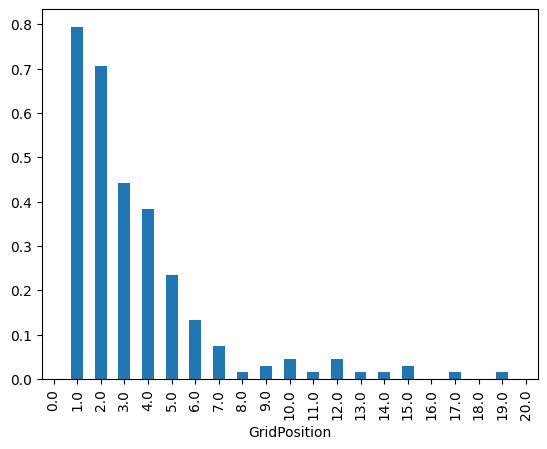

In [35]:
train_df.groupby('GridPosition')['Podium'].mean().plot(kind='bar')

<Axes: >

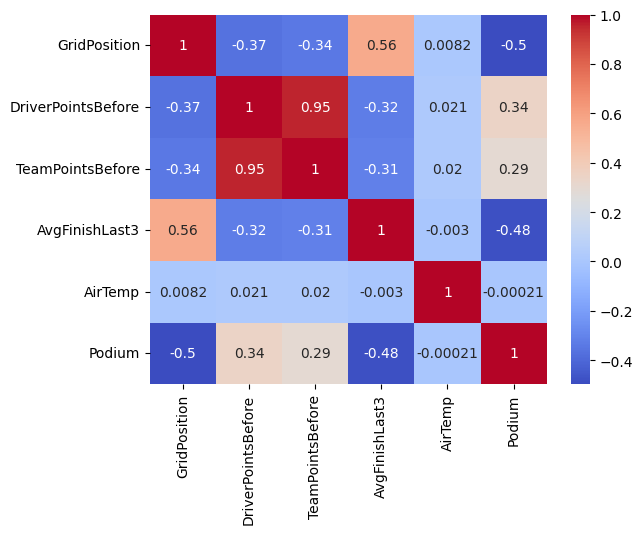

In [36]:
import seaborn as sns

numeric_cols = ['GridPosition', 'DriverPointsBefore', 'TeamPointsBefore', 'AvgFinishLast3', 'AirTemp', 'Podium']

sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm')

In [37]:
# Remove air temp and rainfall only adding noise

cols_to_keep = [
    'Abbreviation',
    'TeamName',
    'GridPosition',
    'DriverPointsBefore',
    'TeamPointsBefore',
    'AvgFinishLast3',
    'Podium'
]

train_df = train_df[cols_to_keep]
test_df = test_df[cols_to_keep]


# Encoding- Make dataset ML ready

In [38]:
from sklearn.preprocessing import LabelEncoder

le_driver = LabelEncoder()
le_team = LabelEncoder()

# Fit on both datasets combined so rookies/new teams are handled
le_driver.fit(pd.concat([train_df['Abbreviation'], test_df['Abbreviation']]))
le_team.fit(pd.concat([train_df['TeamName'], test_df['TeamName']]))

train_df['Abbreviation'] = le_driver.transform(train_df['Abbreviation'])
train_df['TeamName'] = le_team.transform(train_df['TeamName'])

test_df['Abbreviation'] = le_driver.transform(test_df['Abbreviation'])
test_df['TeamName'] = le_team.transform(test_df['TeamName'])

In [39]:
train_df.to_csv("data/race_results_22_24_ML_READY.csv", index=False)
test_df.to_csv("data/race_results_25_ML_READY.csv", index=False)

# Models

In [40]:
features = ['Abbreviation', 'TeamName', 'GridPosition', 'DriverPointsBefore', 'TeamPointsBefore', 'AvgFinishLast3']

X_train = train_df[features]
y_train = train_df['Podium']

X_test = test_df[features]
y_test = test_df['Podium']

In [41]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [42]:
lr = LogisticRegression(class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
xgb = XGBClassifier(scale_pos_weight=5)

In [43]:
print(X_train.isnull().sum())

Abbreviation           0
TeamName               0
GridPosition           2
DriverPointsBefore     0
TeamPointsBefore       0
AvgFinishLast3        68
dtype: int64


In [44]:
X_train = X_train.fillna({
    'GridPosition': 20,
    'AvgFinishLast3': 10
})

X_test = X_test.fillna({
    'GridPosition': 20,
    'AvgFinishLast3': 10
})

In [45]:
for model in [lr, rf, xgb]:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
  #  print(model.__class__.__name__)
    print(classification_report(y_test, preds))
    print('---')

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       220
           1       0.51      0.95      0.66        39

    accuracy                           0.85       259
   macro avg       0.75      0.89      0.78       259
weighted avg       0.92      0.85      0.87       259

---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       220
           1       0.78      0.79      0.78        39

    accuracy                           0.93       259
   macro avg       0.87      0.88      0.87       259
weighted avg       0.94      0.93      0.93       259

---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       220
           1       0.64      0.72      0.67        39

    accuracy                           0.90       259
   macro avg       0.79      0.82      0.81       259
weighted avg       0.90      0.90      0.90       259

---


### SHAP analysis

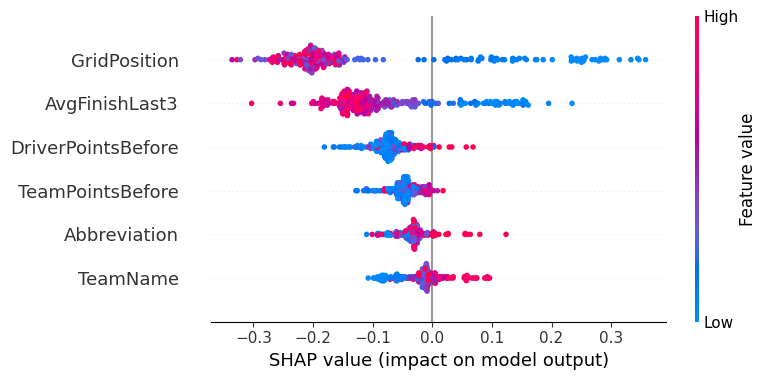

In [46]:
import shap

# SHAP anyalysis for random forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:,:,1], X_test, feature_names=features)

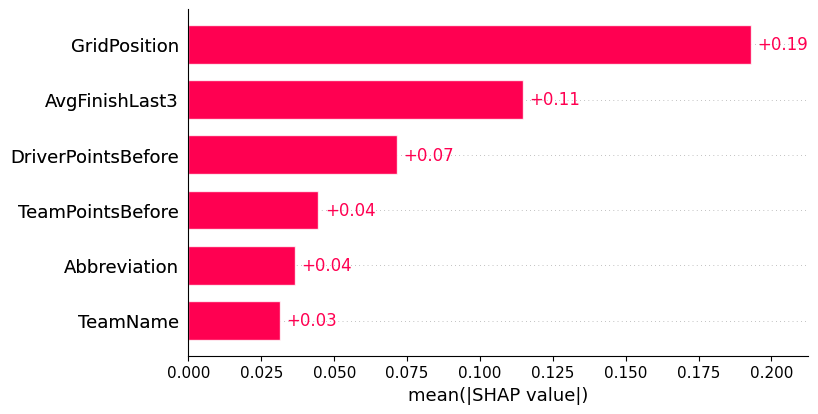

In [47]:
shap.plots.bar(shap_values[:,:,1])

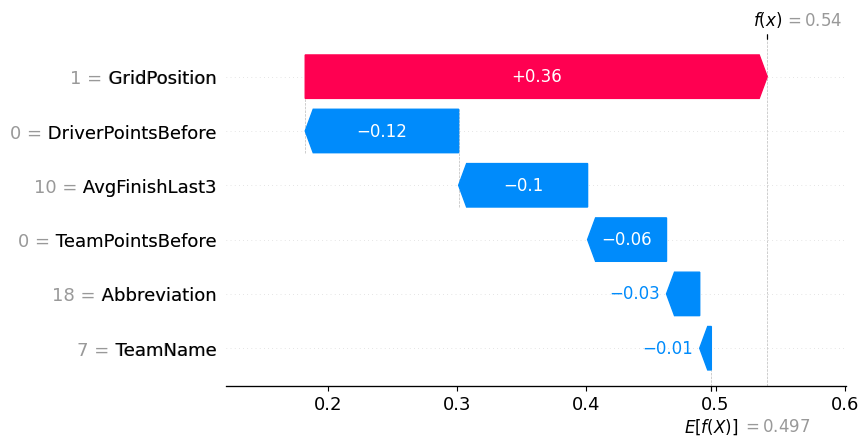

In [48]:
shap.plots.waterfall(shap_values[0,:,1])

In [49]:
# Add Neural Netowrk

from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
preds = nn.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       220
           1       0.67      0.41      0.51        39

    accuracy                           0.88       259
   macro avg       0.78      0.69      0.72       259
weighted avg       0.87      0.88      0.87       259



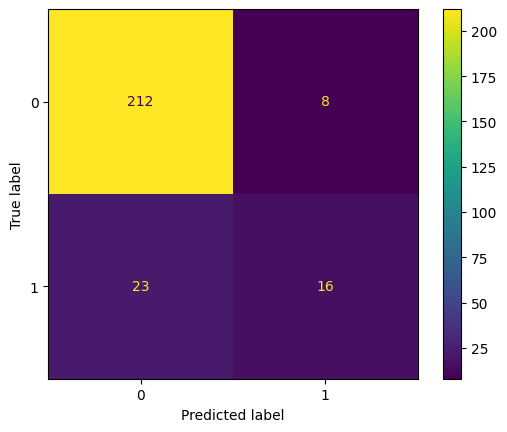

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(nn, X_test, y_test)

In [53]:
# Comparison

from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

results = []
for name, model in [('Logistic Regression', lr), ('Random Forest', rf), 
                     ('XGBoost', xgb), ('Neural Network', nn)]:
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, proba)
    })

pd.DataFrame(results).set_index('Model').round(3)

,Accuracy,F1,AUC
Model,,,
Logistic Regression,0.853,0.661,0.947
Random Forest,0.934,0.785,0.959
XGBoost,0.896,0.675,0.936
Neural Network,0.880,0.508,0.926


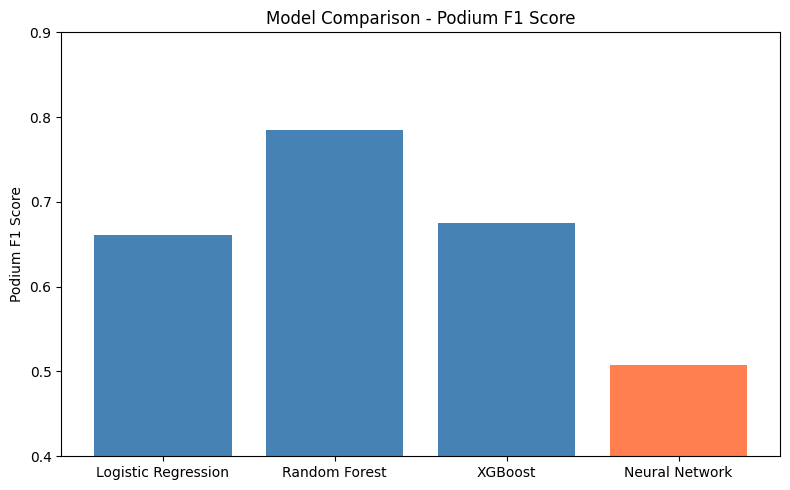

In [57]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']
f1_scores = [0.661, 0.785, 0.675, 0.508]

plt.figure(figsize=(8, 5))
plt.bar(models, f1_scores, color=['steelblue', 'steelblue', 'steelblue', 'coral'])
plt.ylabel('Podium F1 Score')
plt.title('Model Comparison - Podium F1 Score')
plt.ylim(0.4, 0.9)
plt.tight_layout()
plt.show()